In [1]:
import napari
import numpy as np
from skimage.io import imread
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import mutual_info_score
import os
%matplotlib inline

In [2]:
fig_out_folder = './figures/'
isExist = os.path.exists(fig_out_folder)
if not isExist:

   # Create a new directory because it does not exist
   os.makedirs(fig_out_folder)

In [51]:
folder = '../../IMC_SegmentationResults/Leap001/'
file_name = 'Leap001_008.tiff'
img = imread(folder+'img/'+file_name)
panel = pd.read_csv(folder+'panel.csv')
panel = panel[panel.keep==1]
panel.name = panel.name.str.split('-',n=1).str.get(1)
panel.reset_index(drop = True,inplace=True)


This script reads the file img data, and shows in napari with the protein tag

In [9]:

viewer = napari.Viewer()
layer = viewer.add_image(img, name=panel.name,channel_axis=0)

In [19]:
reshaped_data = img.reshape(img.shape[0],-1)
corr = pd.DataFrame(np.corrcoef(reshaped_data),index = panel.name,columns=panel.name)

<Figure size 640x480 with 0 Axes>

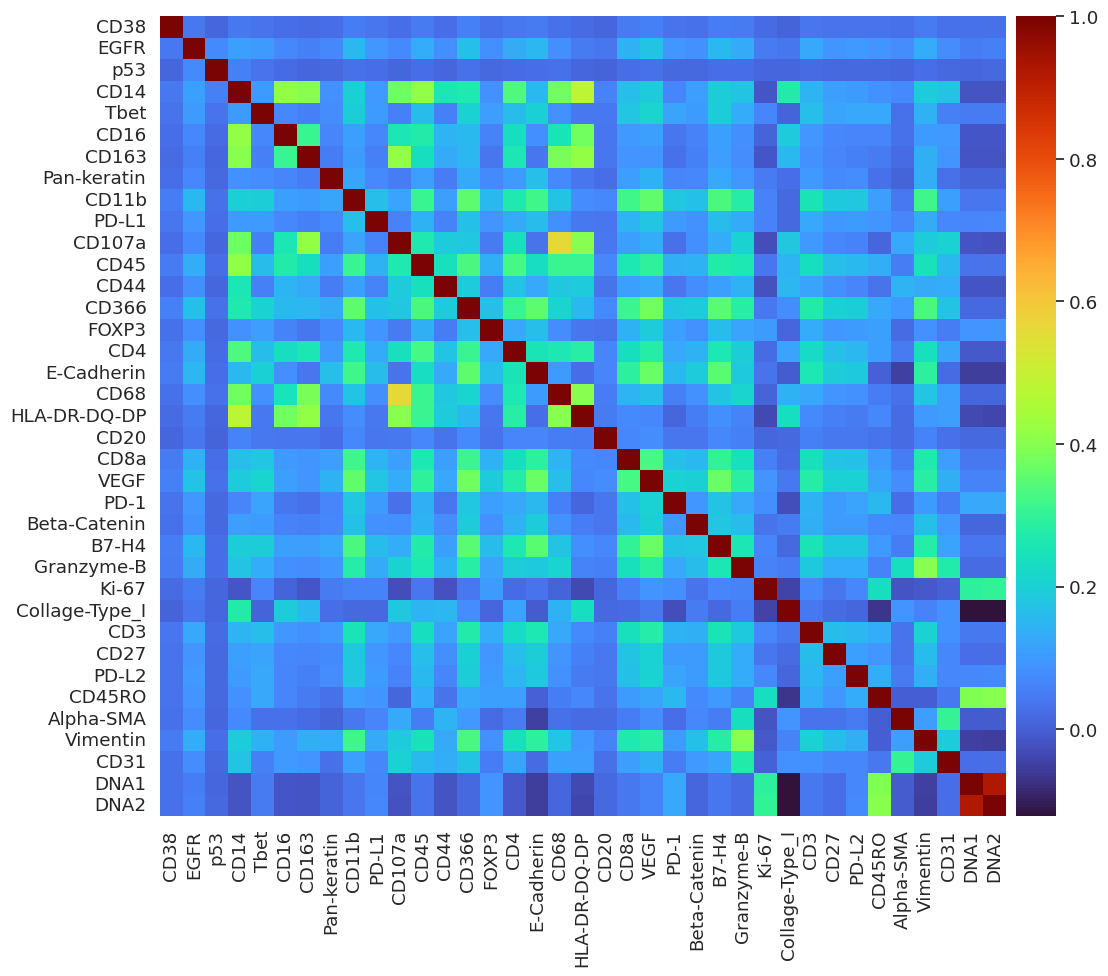

In [20]:
plt.tight_layout()
sns.set(font_scale=1.2)
plt.figure(figsize=(12,10))
ax = sns.heatmap(corr,cmap='turbo',cbar_kws={'pad':0.01})
ax.set(xlabel=None)
ax.set(ylabel=None)
plt.tight_layout()
plt.savefig(fig_out_folder+'all_marker.png')

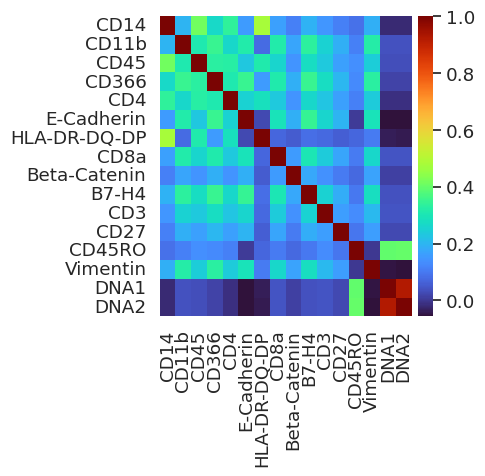

In [21]:

segm_markers = panel[~panel.deepcell.isna()].name
plt.figure(figsize=(5,5))
ax = sns.heatmap(corr.loc[segm_markers,segm_markers],cmap='turbo',cbar_kws={'pad':0.02})
ax.set(xlabel=None)
ax.set(ylabel=None)
plt.tight_layout()
plt.savefig(fig_out_folder+'our_marker.png')

# Creating the nuclei and membrane mask

Rescale cythoplasm marker expression and take the average

In [43]:
img_cyth = np.zeros((img.shape[1:]))#same x,y dimensions as per original pixel
for indx,marker in enumerate(img[panel.deepcell==2]):
    a = marker[marker>0]
    if len(a) > 0:
        img_percentile = np.quantile(a,  q= .99)
        img_cyth += marker/img_percentile
img_cyth= img_cyth/len(img[panel.deepcell==2])

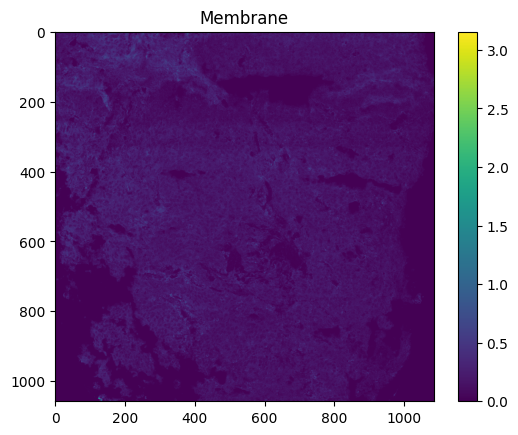

In [44]:
plt.title('Membrane')
plt.imshow(img_cyth)
plt.colorbar()


In [45]:
img_nucl = np.zeros((img.shape[1:]))#same x,y dimensions as per original pixel
for marker in img[panel.deepcell==1]:
    a = marker[marker>0]
    if len(a) > 0:
        img_percentile = np.quantile(a,  q= .99)
        img_nucl += marker/img_percentile
img_nucl= img_nucl/len(img[panel.deepcell==1])

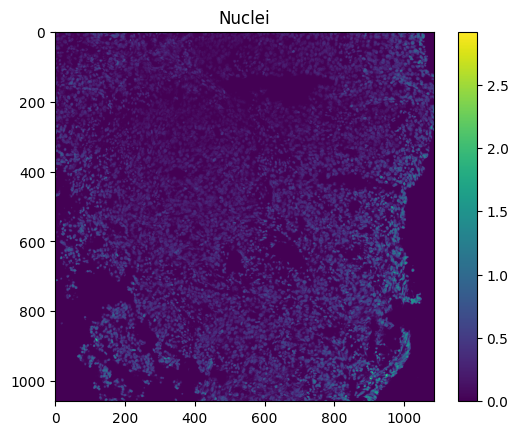

In [46]:
plt.title('Nuclei')
plt.imshow(img_nucl)
plt.colorbar()

In [49]:
viewer = napari.Viewer()
viewer.add_image(img_cyth,name='cythoplasm')
viewer.add_image(img_nucl,name='nuclei')

<Image layer 'nuclei' at 0x7ff24287b040>

In [59]:
dic = {'nuclei':img_nucl,'cythoplasm':img_cyth,'file_name':file_name}#create an object to store the two masks

import pickle
segm_input_folder = './input_segmentation/'
isExist = os.path.exists(segm_input_folder)
if not isExist:
    os.makedirs(segm_input_folder)
with open(segm_input_folder+file_name.split('.')[0], 'wb') as outp:  # Overwrites any existing file.
    pickle.dump(dic, outp, pickle.HIGHEST_PROTOCOL)